# Exploratory Analysis and Correlations

In this notebook, we explore relationships between the target variable and key predictors through visualizations and correlation analysis.
The goal is to understand which features show meaningful associations with the target and which do not.

In [1]:
# ========================================================
# IMPORTS, SETTINGS, AND LOAD DATA
# ========================================================

# ----------------------------------------------------------
# IMPORTS
# ----------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf


# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

time_res = "qh"   # "h" or "qh"
target_var = "id1"


# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df = pd.read_csv(
    f"../data/combined_data_{time_res}.csv",
    parse_dates=["datetime"]
)

df["datetime"] = (
    pd.to_datetime(df["datetime"], utc=True)
      .dt.tz_convert("Europe/Vienna")
)

df = df.sort_values("datetime").reset_index(drop=True)

print(df.shape)
df.head()

(140256, 132)


,datetime,load_forecast_mw,load_actual_mw,solar_day_ahead,solar_current,wind_day_ahead,wind_current,biomass_mw,fossil_gas_mw,fossil_hard_coal_mw,...,load_delta,wind_delta,solar_delta,wind_delta_c,solar_delta_c,residual_load,total_production_mw,gas_share,total_outage_true,ramp_outage
0,2022-01-01 00:00:00+01:00,5909.6,6152.0,0.0,0.0,2176.0,2000.0,336.0,93.6,0.0,...,242.4,-80.0,0.0,-176.0,0.0,228.4,6708.0,0.013953,601.5,NaN
1,2022-01-01 00:15:00+01:00,5819.6,6040.0,0.0,0.0,2268.0,2140.0,336.0,91.2,0.0,...,220.4,136.0,0.0,-128.0,0.0,-142.4,6969.6,0.013085,601.5,0.0
2,2022-01-01 00:30:00+01:00,5731.6,5940.0,0.0,0.0,2360.0,2300.0,336.0,92.8,0.0,...,208.4,144.0,0.0,-60.0,0.0,-344.4,7084.4,0.013099,601.5,0.0
3,2022-01-01 00:45:00+01:00,5640.8,5840.0,0.0,0.0,2456.0,2424.0,332.0,91.6,0.0,...,199.2,180.0,0.0,-32.0,0.0,-578.8,7217.6,0.012691,601.5,0.0
4,2022-01-01 01:00:00+01:00,5709.6,5812.0,0.0,0.0,2516.0,2504.0,332.0,92.0,0.0,...,102.4,124.0,0.0,-12.0,0.0,-593.2,7149.2,0.012869,601.5,0.0


### Correlation overview

First we have a look at the correlation of some basic fundamentals and the target.

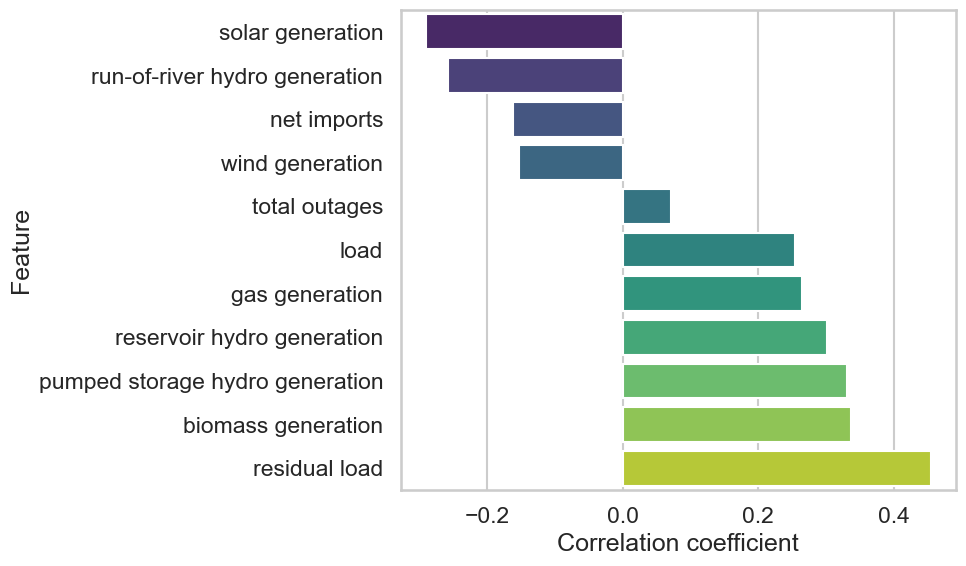

Correlation of features with ID1:
solar generation: -0.2905
run-of-river hydro generation: -0.2575
net imports: -0.1614
wind generation: -0.1526
total outages: 0.0710
load: 0.2546
gas generation: 0.2650
reservoir hydro generation: 0.3017
pumped storage hydro generation: 0.3309
biomass generation: 0.3364
residual load: 0.4545


In [ ]:
# ========================================================
# CORRELATION OF FEATURES WITH TARGET VARIABLE
# ========================================================

cols_for_absolute_corr = [
    "load_actual_mw", 
    "net_import_total",
    "wind_onshore_mw",
    "solar_mw",
    "fossil_gas_mw",
    "biomass_mw",
    "hydro_run_of_river_and_poundage_mw",
    "hydro_water_reservoir_mw",
    "hydro_pumped_storage_mw", 
    "residual_load",
    "outage_total_true"
]

cor_df = df[["datetime", target_var] + cols_for_absolute_corr].copy()

cor_df.rename(columns={
    "net_import_total": "net imports", 
    "load_actual_mw": "load",
    "wind_onshore_mw": "wind generation", 
    "solar_mw": "solar generation", 
    "fossil_gas_mw": "gas generation",
    "biomass_mw": "biomass generation",
    "hydro_run_of_river_and_poundage_mw": "run-of-river hydro generation",
    "hydro_water_reservoir_mw": "reservoir hydro generation",
    "hydro_pumped_storage_mw": "pumped storage hydro generation",
    "residual_load": "residual load",
    "outage_total_true": "total outages"
}, inplace=True)

level_corr_to_target = (
    cor_df.corr(numeric_only=True)[target_var]
    .drop(target_var)
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=level_corr_to_target.values,
    y=level_corr_to_target.index,
    hue=level_corr_to_target.index,
    palette="viridis",
    legend=False
)

#plt.title(f"Correlation of features with {target_var.upper()}")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# print the correlation values in a table format
print(f"Correlation of features with {target_var.upper()}:")

# Print each feature correlation in sorted order
for feature, corr_value in level_corr_to_target.items():
    print(f"{feature}: {corr_value:.4f}")

### 1. Correlation with DA 

Since DA is a natural predictor for ID prices we compare them with a scatterplot.

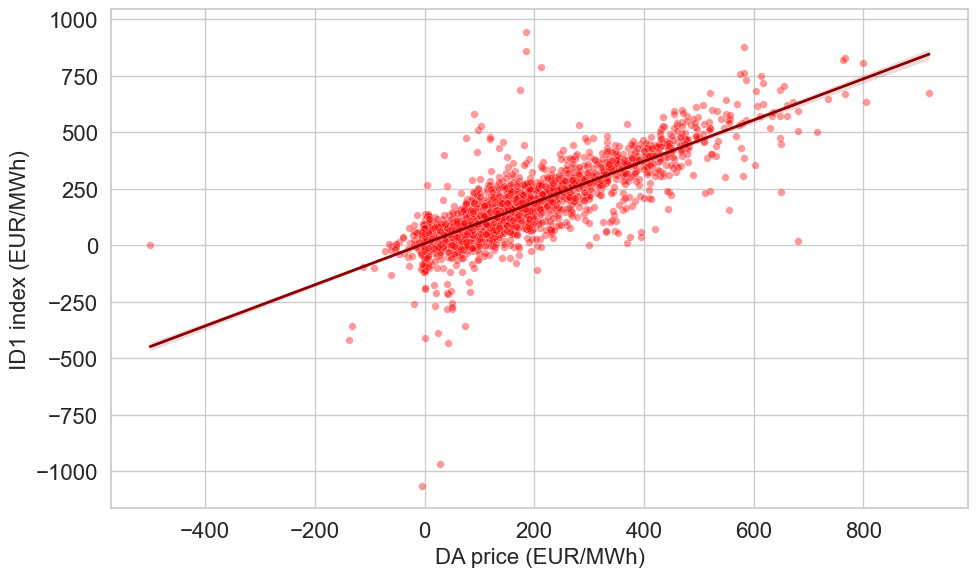

In [36]:
# ========================================================
# ID PRICE VS. DAY-AHEAD PRICE 
# ========================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(len(df), 5000), random_state=42),
    x="day_ahead_price",
    y="id1",
    alpha=0.4,
    s=30, 
    color="red"
)
sns.regplot(
    data=df.sample(min(len(df), 5000), random_state=42),
    x="day_ahead_price",
    y="id1",
    scatter=False,
    line_kws={"color":"darkred", "linewidth":2}
)
#plt.title("ID1 price vs. Day-ahead price")
plt.xlabel("DA price (EUR/MWh)")
plt.ylabel("ID1 index (EUR/MWh)")

plt.tight_layout()
plt.show()

### 2. Time-based Features

We begin by examining the relationship between the target and **time-related features** hour of the day and day of the week. These plots help reveal potential temporal patterns or seasonality effects that may influence price dynamics.

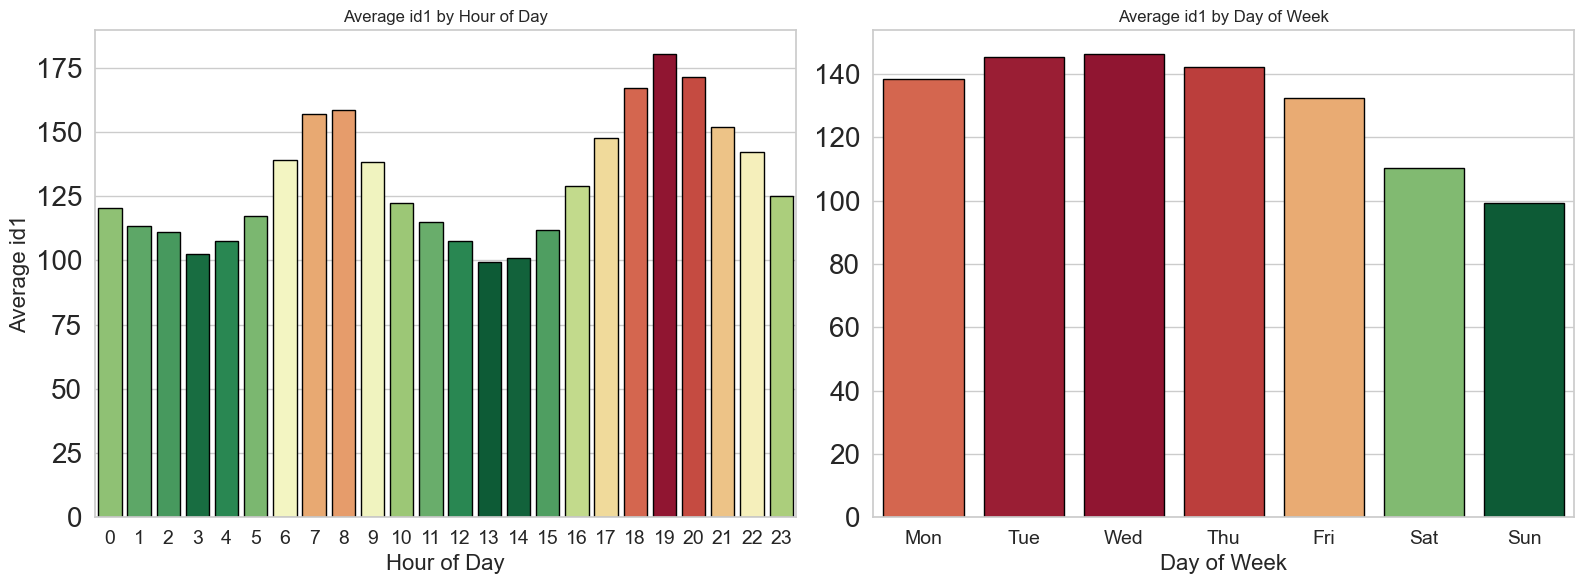

In [12]:
# ========================================================
# Time Plots
# ========================================================

# Define color palette from green (low) to red (high)
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)

# Prepare figure and axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style='whitegrid')

# ---------------------------------------------------------
# Plot: Target by Hour of Day and Day of Week
# ---------------------------------------------------------

# Target by Hour of Day 
hour_means = df.groupby("hour")[target_var].mean()
colors_hour = cmap((hour_means - hour_means.min()) / (hour_means.max() - hour_means.min()))

sns.barplot(
    x=hour_means.index,
    y=hour_means.values,
    hue=hour_means.index,
    ax=axes[0],
    palette=list(colors_hour),
    edgecolor='black',
    legend=False
)
axes[0].set_title(f"Average {target_var} by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel(f"Average {target_var}")

# Target by Day of Week
dow_means = df.groupby("day_of_week")[target_var].mean()
colors_dow = cmap((dow_means - dow_means.min()) / (dow_means.max() - dow_means.min()))

sns.barplot(
    x=dow_means.index,
    y=dow_means.values,
    hue=dow_means.index,
    ax=axes[1],
    palette=list(colors_dow),
    edgecolor='black',
    legend=False
)
axes[1].set_title(f"Average {target_var} by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("")
axes[1].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

# Layout and display
plt.tight_layout()
plt.show()

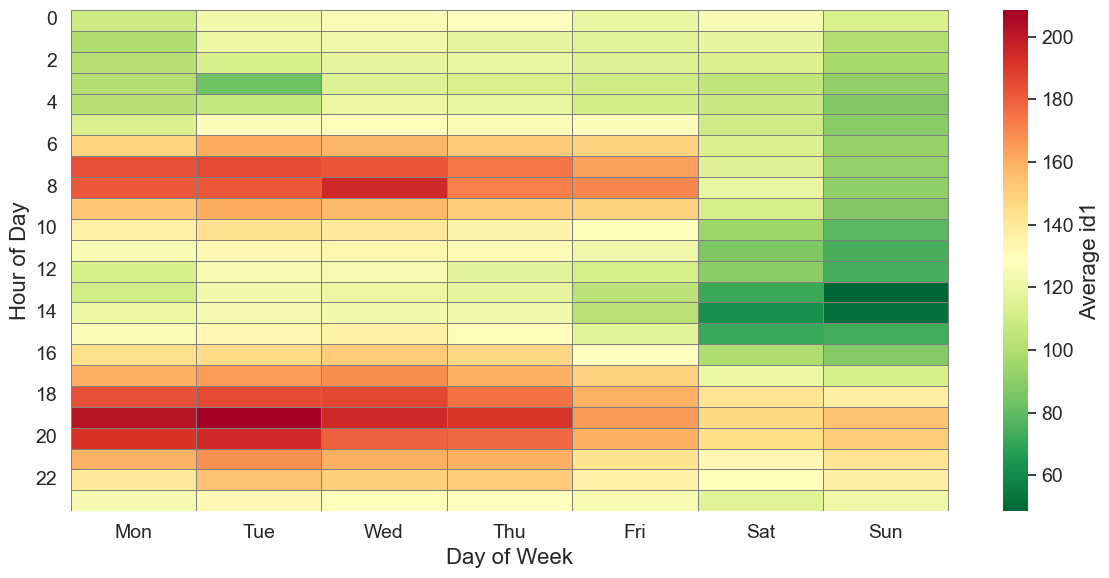

In [26]:
# ----------------------------------------------------------
# Plot: combined Target by Hour of Day and Day of Week: heatmap
# ----------------------------------------------------------

heatmap_data = df.groupby(["hour", "day_of_week"])[target_var].mean().unstack()
sns.heatmap(
    heatmap_data,
    cmap="RdYlGn_r",
    #annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': f'Average {target_var}'}
)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "legend.title_fontsize": 14,
})

#plt.title(f"Average {target_var} by Hour of Day and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.xticks(ticks=np.arange(7) + 0.5, labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

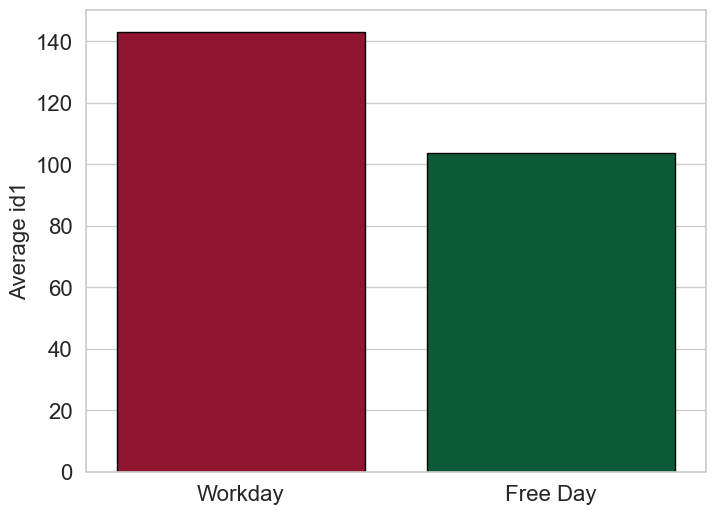

In [27]:
# ----------------------------------------------------------
# Plot: Target by Free Day vs Workday
# ----------------------------------------------------------

# 1 = free day, 0 = workday
free_day_means = df.groupby("free_day")[target_var].mean()
colors_free_day = cmap((free_day_means - free_day_means.min()) / (free_day_means.max() - free_day_means.min()))
plt.figure(figsize=(8, 6))
sns.barplot(
    x=free_day_means.index,
    y=free_day_means.values,
    hue=free_day_means.index,
    palette=list(colors_free_day),
    edgecolor='black',
    legend=False
)
#plt.title(f"Average {target_var} by Free Day vs Workday")
plt.ylabel(f"Average {target_var}")

# rename x-axis labels
plt.xticks([0, 1], ["Workday", "Free Day"])

# remove x-axis label
plt.xlabel("")

plt.show()

We can see that the time variance might actually be a result of load. Since we can see simlar patterns here.

### 3. Production Mix Correlations
We then investigate correlations between the target and **production share variables**, such as the proportion of gas, wind and solar.
It shows that high gas production results in higher prices and vice verca for wind and solar. However, the impact seems to be not that big.

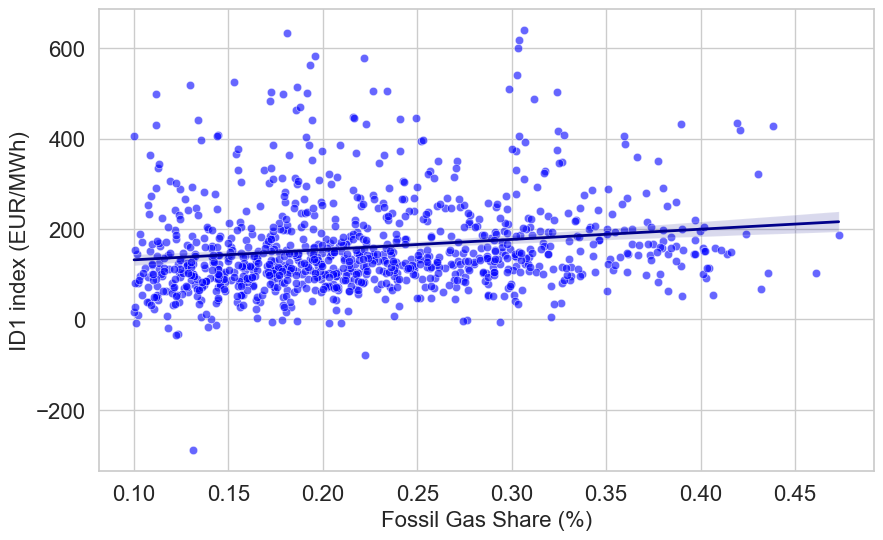

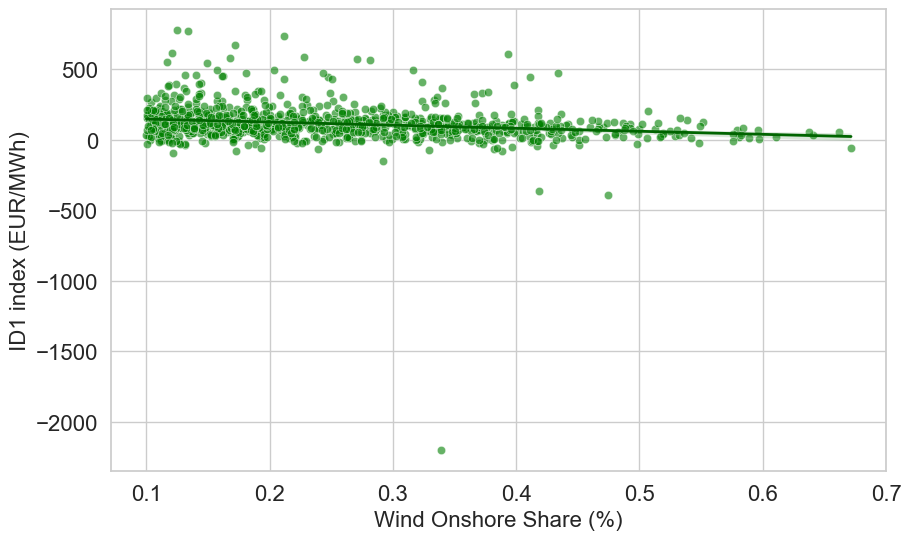

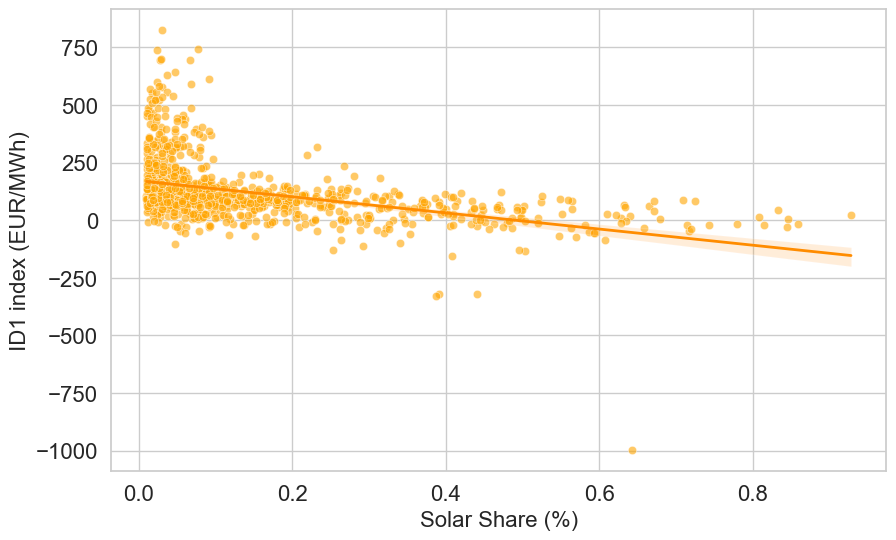

In [37]:
# ========================================================
# PLOTS:SHARE OF GENERATION TYPES IN TOTAL LOAD
# ========================================================

# calculate the share of fossil gas generation, wind onshore generation, and solar generation in total load
df["fossil_gas_share"] = df["fossil_gas_mw"] / df["load_actual_mw"]
df["wind_onshore_share"] = df["wind_onshore_mw"] / df["load_actual_mw"]
df["solar_share"] = df["solar_mw"] / df["load_actual_mw"]

# --------------------------------------------------
# Plot: Target vs Fossil Gas Share 
# --------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="fossil_gas_share", y=target_var, data=df[df["fossil_gas_share"] > 0.1].sample(n=1000, random_state=1), color="blue", alpha=0.6)
#plt.title(f"{target_var} by Fossil Gas Share (Sampled)")
sns.regplot(x="fossil_gas_share", y=target_var, data=df[df["fossil_gas_share"] > 0.1].sample(n=1000, random_state=1), scatter=False, line_kws={"color":"darkblue", "linewidth":2})
plt.ylabel("ID1 index (EUR/MWh)")
plt.xlabel("Fossil Gas Share (%)")
plt.show()

# ---------------------------------------------------
# Plot: Target vs Wind Onshore Share
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="wind_onshore_share", y=target_var, data=df[df["wind_onshore_share"] > 0.1].sample(n=1000, random_state=1), color="green", alpha=0.6)
#plt.title(f"{target_var} by Wind Onshore Share (Sampled)")
sns.regplot(x="wind_onshore_share", y=target_var, data=df[df["wind_onshore_share"] > 0.1].sample(n=1000, random_state=1), scatter=False, line_kws={"color":"darkgreen", "linewidth":2})
plt.ylabel("ID1 index (EUR/MWh)")
plt.xlabel("Wind Onshore Share (%)")
plt.show()

# ---------------------------------------------------
# Plot: Target vs Solar Share
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="solar_share", y=target_var, data=df[df["solar_share"] > 0.01].sample(n=1000, random_state=1), color="orange", alpha=0.6)
#plt.title(f"{target_var} by Solar Share (Sampled, min solar_share=0.01)")
sns.regplot(x="solar_share", y=target_var, data=df[df["solar_share"] > 0.01].sample(n=1000, random_state=1), scatter=False, line_kws={"color":"darkorange", "linewidth":2})
plt.ylabel("ID1 index (EUR/MWh)")
plt.xlabel("Solar Share (%)")
plt.show()

### 4. Forecast Delta Analysis
Finally, we analyze the correlation between forecast deltas (e.g., deviations between forecasted and actual values of load and production) and the target variable.
The results indicate that these forecast deltas show little to no correlation with the target, suggesting limited predictive value for this feature group.

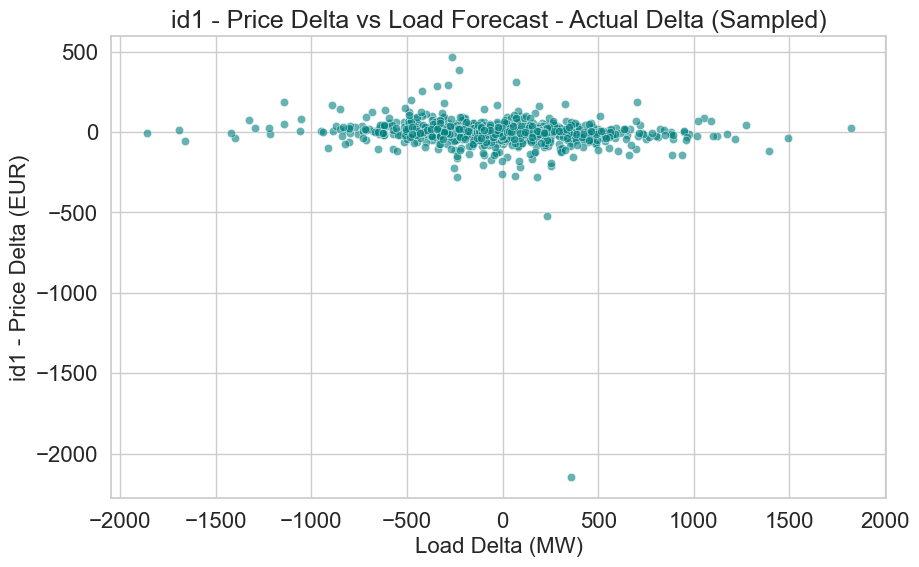

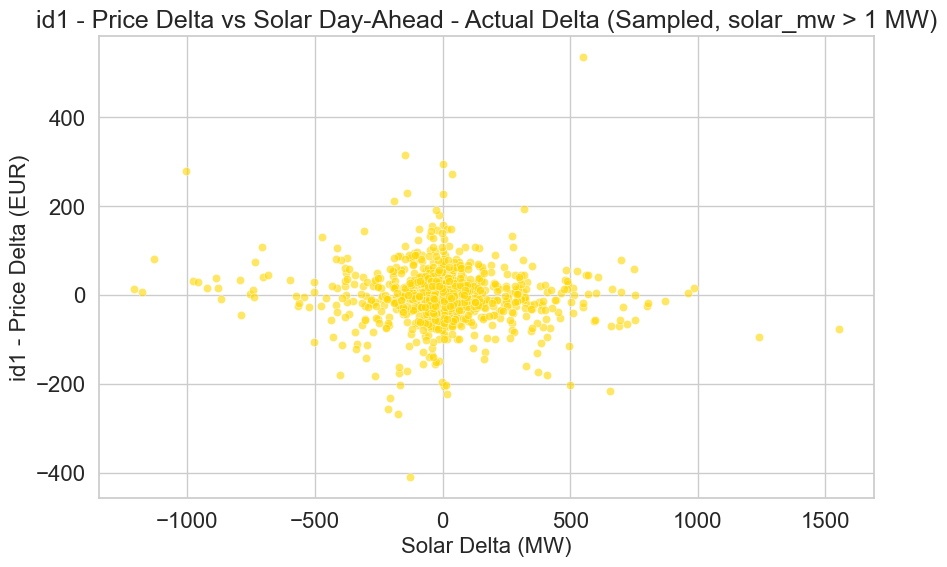

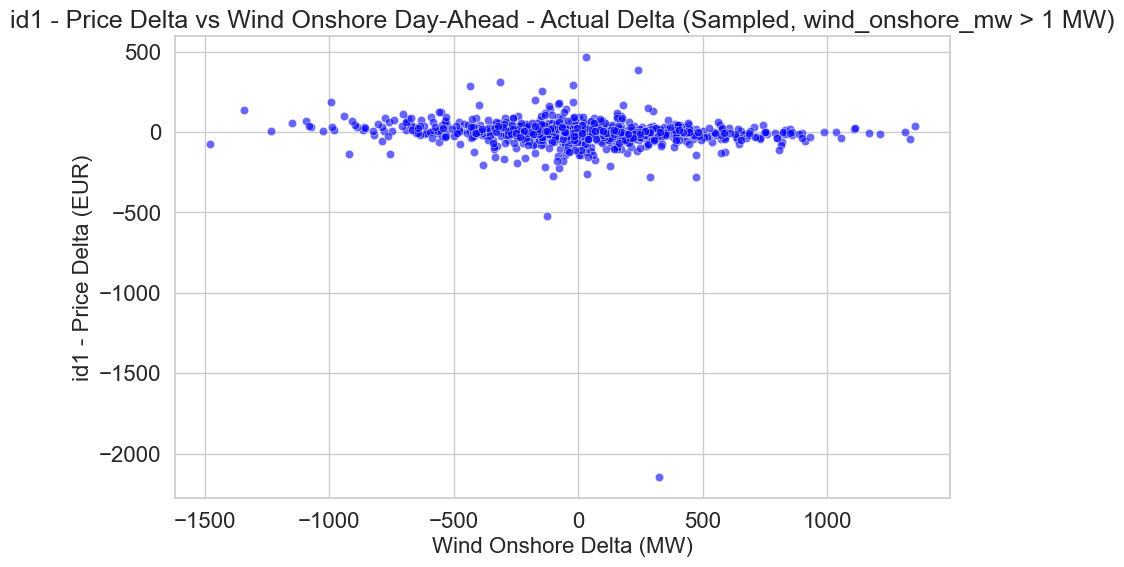

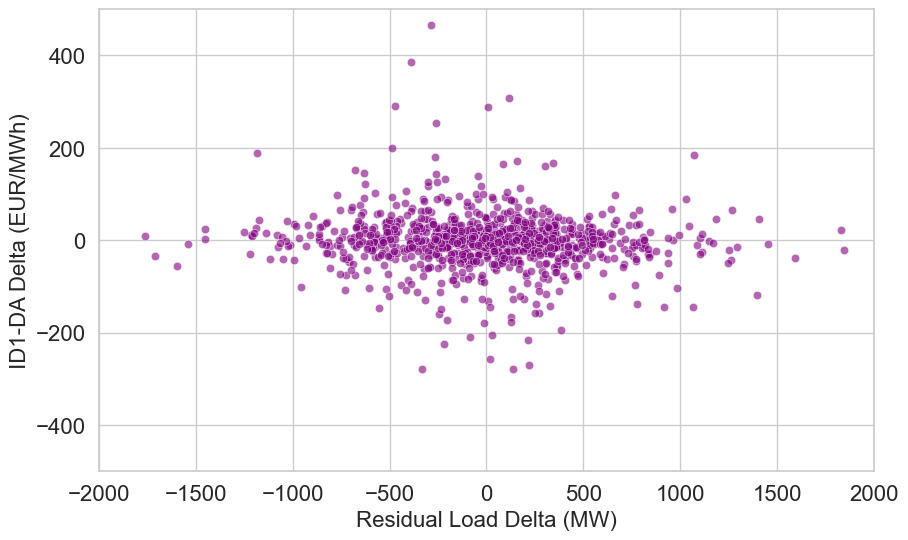

In [46]:
# ========================================================
# PLOTS: DELTA VARIABLES
# ========================================================

# create delta variables
df[f"{target_var}_price_delta"] = df[target_var] - df["day_ahead_price"]
df["load_delta"] = df["load_actual_mw"] - df["load_forecast_mw"]

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "legend.title_fontsize": 14,
})


# ----------------------------------------------------------
# Plot: Target Price Delta vs Load Forecast - Actual Delta
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="load_delta", y=f"{target_var}_price_delta", data=df.sample(n=1000, random_state=1), color="teal", alpha=0.6)
plt.title(f"{target_var} - Price Delta vs Load Forecast - Actual Delta (Sampled)")
plt.xlabel("Load Delta (MW)")
plt.ylabel(f"{target_var} - Price Delta (EUR)")
plt.show()

# ----------------------------------------------------------
# Plot: Target Price Delta vs Solar Day-Ahead - Actual Delta
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="solar_delta", y=f"{target_var}_price_delta", data=df[df["solar_mw"] > 1].sample(n=1000, random_state=1), color="gold", alpha=0.6)
plt.title(f"{target_var} - Price Delta vs Solar Day-Ahead - Actual Delta (Sampled, solar_mw > 1 MW)")
plt.xlabel("Solar Delta (MW)")
plt.ylabel(f"{target_var} - Price Delta (EUR)")
plt.show()

# ----------------------------------------------------------
# Plot: Target Price Delta vs Wind Onshore Day-Ahead - Actual Delta
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="wind_delta", y=f"{target_var}_price_delta", data=df[df["wind_onshore_mw"] > 1].sample(n=1000, random_state=1), color="blue", alpha=0.6)
plt.title(f"{target_var} - Price Delta vs Wind Onshore Day-Ahead - Actual Delta (Sampled, wind_onshore_mw > 1 MW)")
plt.xlabel("Wind Onshore Delta (MW)")
plt.ylabel(f"{target_var} - Price Delta (EUR)")
plt.show()

# calc residual_load_delta and plot against price delta
df["residual_load_forecast"] = df["load_forecast_mw"] \
    - df["wind_day_ahead"] - df["solar_day_ahead"] - df["hydro_run_of_river_and_poundage_mw"]

df["residual_load_current"] = df["load_actual_mw"] \
    - df["wind_current"] - df["solar_current"] - df["hydro_run_of_river_and_poundage_mw"]

df["residual_load_delta"] = df["residual_load_current"] - df["residual_load_forecast"]


# ----------------------------------------------------------
# Plot: Target Price Delta vs Residual Load Forecast - Actual Delta
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="residual_load_delta", y=f"{target_var}_price_delta", data=df.sample(n=1000, random_state=1), color="purple", alpha=0.6)
#plt.title(f"{target_var} - Price Delta vs Residual Load Forecast - Actual Delta (Sampled)")
plt.xlabel("Residual Load Delta (MW)")
plt.ylabel(f"ID1-DA Delta (EUR/MWh)")
#set x and y limits to zoom in on the main cluster of points
plt.xlim(-2000, 2000)
plt.ylim(-500, 500)
#add regression line
#sns.regplot(x="residual_load_delta", y=f"{target_var}_price_delta", data=df.sample(n=1000, random_state=1),
#            scatter=False, line_kws={"color":"darkmagenta", "linewidth":2})
plt.show()

### 5. Autocorrelation

At last we check the autocorrelation of ID prices. 

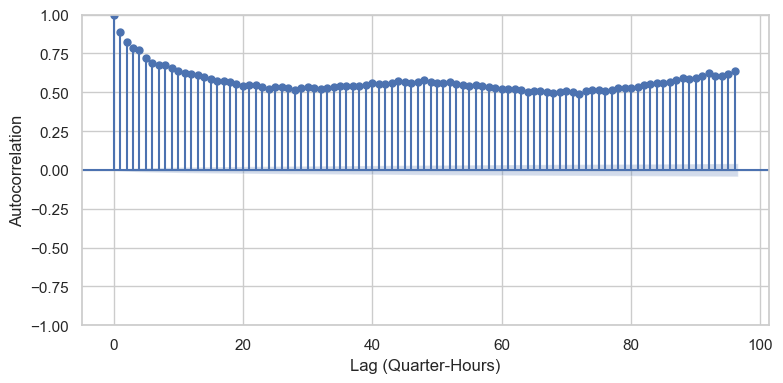

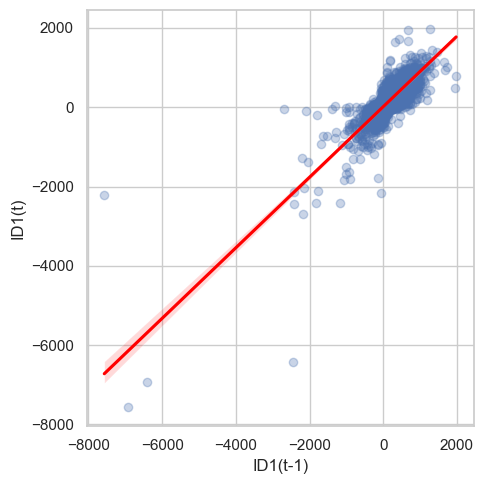

In [42]:
# ========================================================
# PLOTS: AUTOCORRELATION
# ========================================================

# --------------------------------------------------
# Plot: Autocorrelation Function of ID1 Prices
# --------------------------------------------------

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "legend.title_fontsize": 14,
})


sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8,4))
plot_acf(df["id1"].dropna(), lags=96, ax=ax)

#ax.set_title("Autocorrelation Function of ID1 Prices")
ax.set_title("")
ax.set_xlabel("Lag (Quarter-Hours)")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot: Lag Plot of ID1 Prices (Lag 1)
# --------------------------------------------------

sns.set_theme(style="whitegrid")

plt.figure(figsize=(5,5))
sns.regplot(
    x=df["id1"].shift(1),
    y=df["id1"],
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.xlabel("ID1(t-1)")
plt.ylabel("ID1(t)")
#plt.title("Lag Plot of ID1 Prices (Lag 1)")
plt.tight_layout()
plt.show()